# Import Libraries

In [1]:
import pandas as pd
import numpy as np
import pickle
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.metrics import classification_report, confusion_matrix
from torch.utils.data import Dataset
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing.sequence import pad_sequences
from transformers import DistilBertTokenizer, DistilBertForSequenceClassification
from transformers import BertTokenizer, BertForSequenceClassification, Trainer

c:\Users\VICTUS\OneDrive\Documents\Semester_4\ML\ML\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Load Test Data

In [2]:
test_df = pd.read_csv('../data/data_test_master.csv')
test_df.head()

,clean_text,emotion
0,i love how adgag laws are legalized illegal ac...,Love
1,ah lol just run then,Joy
2,what a time to be alive,Surprise
3,i love this game but even i'm not spending mon...,Love
4,gotta get out on,Joy


# Splitting Target and Feature

In [3]:
X_test_text = test_df['clean_text'].astype(str).tolist()
y_test_text = test_df['emotion']

print(f"Total Test Data: {len(X_test_text)} rows.")

Total Test Data: 7652 rows.


# Testing

In [4]:
def evaluate_and_plot(y_true, y_pred, label_classes, model_name):
    print(f"=== Classification Report: {model_name} ===")
    print(classification_report(y_true, y_pred, target_names=label_classes))
    
    # Transposisi orientasi matriks (True di X, Prediksi di Y)
    cm = confusion_matrix(y_true, y_pred).T
    
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=label_classes, yticklabels=label_classes)
    plt.title(f'Confusion Matrix - {model_name}')
    plt.xlabel('True Label')
    plt.ylabel('Predicted Label')
    plt.show()

# SVM Evaluation

=== Classification Report: Support Vector Machine (SVM) ===
              precision    recall  f1-score   support

       Anger       0.70      0.72      0.71      1618
        Fear       0.59      0.67      0.63       590
         Joy       0.73      0.65      0.69      1619
        Love       0.80      0.81      0.80      1496
     Sadness       0.67      0.66      0.67      1271
    Surprise       0.65      0.67      0.66      1058

    accuracy                           0.70      7652
   macro avg       0.69      0.70      0.69      7652
weighted avg       0.71      0.70      0.70      7652



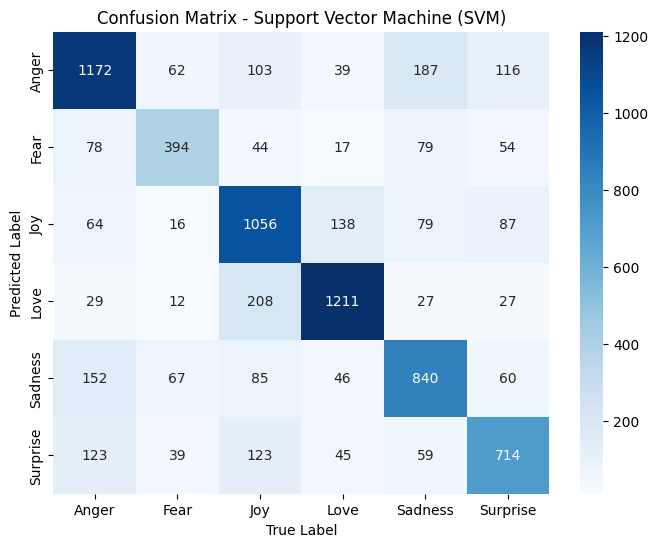

In [5]:
# Load Model
svm_vectorizer = joblib.load('../models/svm/tfidf_vectorizer.joblib')
svm_model = joblib.load('../models/svm/svm_model.joblib')

# Prediction w/ SVM
X_test_svm = svm_vectorizer.transform(X_test_text)
y_pred_svm = svm_model.predict(X_test_svm)

evaluate_and_plot(y_test_text, y_pred_svm, svm_model.classes_, "Support Vector Machine (SVM)")

# Bi-LSTM Evaluation

240/240 [==============================] - 3s 10ms/step
=== Classification Report: Bi-LSTM ===
              precision    recall  f1-score   support

       Anger       0.71      0.72      0.72      1618
        Fear       0.64      0.65      0.64       590
         Joy       0.72      0.64      0.68      1619
        Love       0.76      0.86      0.81      1496
     Sadness       0.66      0.67      0.67      1271
    Surprise       0.67      0.65      0.66      1058

    accuracy                           0.71      7652
   macro avg       0.70      0.70      0.70      7652
weighted avg       0.71      0.71      0.70      7652



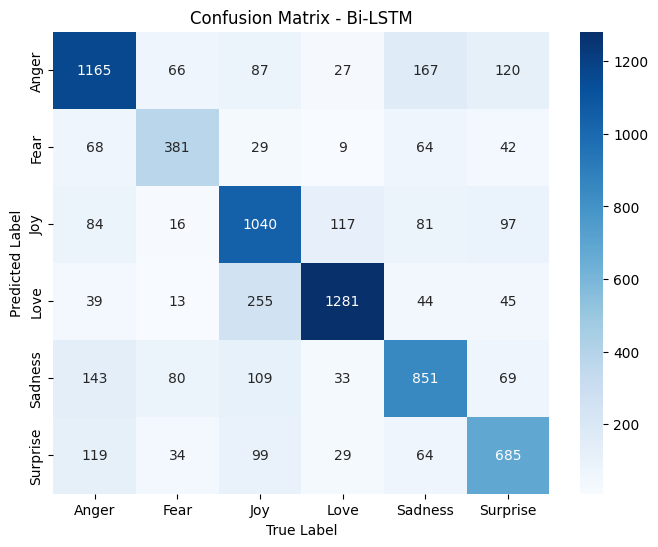

In [6]:
#Load Model
with open('../models/bilstm/tokenizer.pkl', 'rb') as f:
    lstm_tokenizer = pickle.load(f)
with open('../models/bilstm/label_encoder.pkl', 'rb') as f:
    lstm_encoder = pickle.load(f)

bilstm_model = load_model('../models/bilstm/bilstm_model.keras')

# Initialize
X_test_seq = lstm_tokenizer.texts_to_sequences(X_test_text)
X_test_pad = pad_sequences(X_test_seq, maxlen=60, padding='post')
y_test_encoded_lstm = lstm_encoder.transform(y_test_text)

# Prediction Bi-LSTM
y_pred_prob_lstm = bilstm_model.predict(X_test_pad)
y_pred_lstm_encoded = np.argmax(y_pred_prob_lstm, axis=1)
y_pred_lstm = lstm_encoder.inverse_transform(y_pred_lstm_encoded)

evaluate_and_plot(y_test_text, y_pred_lstm, lstm_encoder.classes_, "Bi-LSTM")

# Setup for BERT

In [7]:
class EmotionTestDataset(Dataset):
    def __init__(self, encodings, labels):
        self.encodings = encodings
        self.labels = labels

    def __getitem__(self, idx):
        item = {key: torch.tensor(val[idx]) for key, val in self.encodings.items()}
        item['labels'] = torch.tensor(self.labels[idx], dtype=torch.long)
        return item

    def __len__(self):
        return len(self.labels)

# Load Label Encoder from one of the BERT because its the same Encode
with open('../models/bert/label_encoder.pkl', 'rb') as f:
    hf_encoder = pickle.load(f)

y_test_encoded_hf = hf_encoder.transform(y_test_text)

# DistilBERT Evaluation

100%|██████████| 957/957 [00:06<00:00, 142.35it/s]


=== Classification Report: DistilBERT ===
              precision    recall  f1-score   support

       Anger       0.76      0.79      0.78      1618
        Fear       0.67      0.73      0.70       590
         Joy       0.80      0.72      0.76      1619
        Love       0.83      0.89      0.86      1496
     Sadness       0.76      0.71      0.73      1271
    Surprise       0.70      0.72      0.71      1058

    accuracy                           0.77      7652
   macro avg       0.75      0.76      0.76      7652
weighted avg       0.77      0.77      0.77      7652



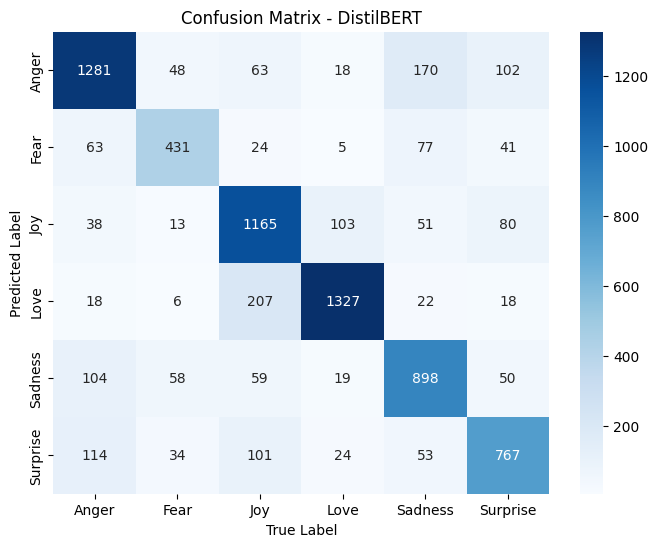

In [8]:
# Load Model
distilbert_tokenizer = DistilBertTokenizer.from_pretrained('../models/bert')
distilbert_model = DistilBertForSequenceClassification.from_pretrained('../models/bert')

# Tokenization 
distilbert_encodings = distilbert_tokenizer(X_test_text, truncation=True, padding=True, max_length=60)
distilbert_dataset = EmotionTestDataset(distilbert_encodings, y_test_encoded_hf)

# Prediction
distilbert_trainer = Trainer(model=distilbert_model)
distilbert_preds = distilbert_trainer.predict(distilbert_dataset)

# Selecting the Most Probable Emotion
y_pred_distilbert_encoded = np.argmax(distilbert_preds.predictions, axis=1)
y_pred_distilbert = hf_encoder.inverse_transform(y_pred_distilbert_encoded)

evaluate_and_plot(y_test_text, y_pred_distilbert, hf_encoder.classes_, "DistilBERT")

# BERT-Base Evaluation

100%|██████████| 957/957 [00:12<00:00, 78.06it/s]


=== Classification Report: BERT-base ===
              precision    recall  f1-score   support

       Anger       0.76      0.78      0.77      1618
        Fear       0.67      0.71      0.69       590
         Joy       0.79      0.72      0.75      1619
        Love       0.82      0.88      0.85      1496
     Sadness       0.73      0.73      0.73      1271
    Surprise       0.72      0.70      0.71      1058

    accuracy                           0.76      7652
   macro avg       0.75      0.75      0.75      7652
weighted avg       0.76      0.76      0.76      7652



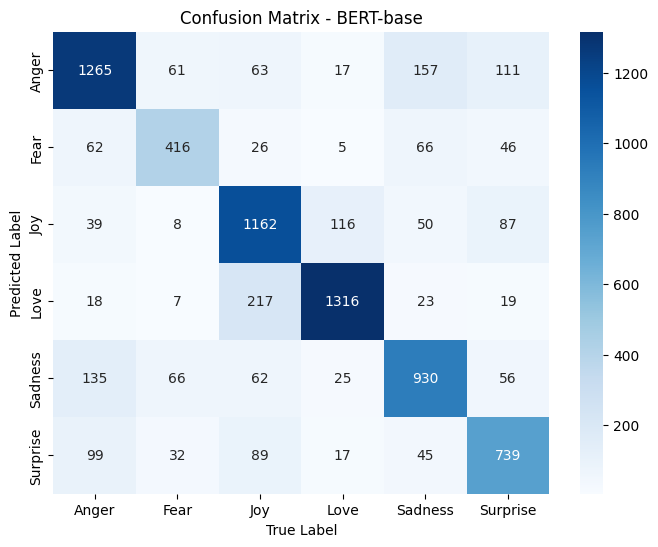

In [9]:
# Load Model
bert_base_tokenizer = BertTokenizer.from_pretrained('../models/bert-base')
bert_base_model = BertForSequenceClassification.from_pretrained('../models/bert-base')

# Tokenization
bert_base_encodings = bert_base_tokenizer(X_test_text, truncation=True, padding=True, max_length=60)
bert_base_dataset = EmotionTestDataset(bert_base_encodings, y_test_encoded_hf)

# Prediction
bert_base_trainer = Trainer(model=bert_base_model)
bert_base_preds = bert_base_trainer.predict(bert_base_dataset)

# Selecting the Most Probable Emotion
y_pred_bert_base_encoded = np.argmax(bert_base_preds.predictions, axis=1)
y_pred_bert_base = hf_encoder.inverse_transform(y_pred_bert_base_encoded)

evaluate_and_plot(y_test_text, y_pred_bert_base, hf_encoder.classes_, "BERT-base")

After going through the evaluation phase, we decided to choose DistilBERT as the final model. Even though its performance only differs slightly from BERT-base, DistilBERT provides significantly better computational efficiency with a much lighter architecture and faster training process. 

However, the overall performance is still relatively limited due to challenges such as class imbalance and the subjective nature of emotion classification. Therefore, further hyperparameter tuning and additional data handling strategies will be conducted to improve the model performance.